In [1]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split , cross_validate
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder , MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix , recall_score , ConfusionMatrixDisplay , precision_score , f1_score



In [2]:
dataframe = pd.read_csv("../processed_data/procesed_customer_churn.csv")
df = dataframe.copy()

In [3]:
df.sample(7)

,Unnamed: 0,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
93827,93827,96555,35,Female,38,20,4,15,Standard,Quarterly,709.00,2,1
324287,324287,331403,49,Male,23,13,0,9,Standard,Annual,633.99,8,0
333437,333437,340553,20,Female,31,4,0,0,Standard,Quarterly,573.09,3,0
50113,50113,50911,51,Female,16,17,1,0,Premium,Monthly,896.00,26,1
31005,31005,31014,40,Male,39,22,1,12,Standard,Annual,278.00,28,1
328236,328236,335352,36,Male,30,4,2,10,Standard,Quarterly,950.87,10,0
128102,128102,132268,56,Female,17,7,0,2,Premium,Annual,571.00,15,1


drop customer id and unnamedd cloumns

Age: min max scale 

Gender = one hot encode 

Subscription_type = one hot encode 







In [4]:
df = df.drop(columns=['Unnamed: 0' , 'CustomerID'])

In [5]:
df.sample(7)

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
269479,44,Male,40,19,4,2,Premium,Quarterly,511.48,5,0
184036,29,Female,59,27,5,22,Basic,Quarterly,502.00,2,1
347428,26,Male,30,22,1,5,Basic,Quarterly,890.42,9,0
342267,49,Male,31,21,2,4,Basic,Quarterly,827.39,5,0
66266,46,Female,8,11,8,24,Standard,Monthly,304.00,2,1
140193,32,Female,55,3,2,25,Standard,Monthly,737.00,13,1
416201,36,Male,6,17,2,4,Basic,Annual,648.93,1,0


# Model Training 


In [6]:
df.shape

(440832, 11)

In [7]:
X = df.drop(columns=["Churn"])
Y = df["Churn"]


In [8]:
X.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,30,Female,39,14,5,18,Standard,Annual,932.0,17
1,65,Female,49,1,10,8,Basic,Monthly,557.0,6
2,55,Female,14,4,6,18,Basic,Quarterly,185.0,3
3,58,Male,38,21,7,7,Standard,Monthly,396.0,29
4,23,Male,32,20,5,8,Basic,Monthly,617.0,20


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [10]:
preprocessor = ColumnTransformer(
    transformers= [
        ("num_scalar" , MinMaxScaler() , ["Age" ,"Tenure" ,"Usage Frequency","Support Calls", "Payment Delay","Total Spend","Last Interaction"]),
        ("cat_encoder" , OneHotEncoder(drop="first", sparse_output=False) , ["Gender" ,"Subscription Type" , "Contract Length"])

    ],
    remainder="passthrough"
)

In [11]:
lg_pipe = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model",  LogisticRegression(random_state=42))

]
)
    

### Cross Validation:

In [12]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cr_val_score = cross_validate(lg_pipe , X_train , y_train , cv=5 , scoring=scoring)
print("Mean Accuracy:", cr_val_score["test_accuracy"].mean())
print("Mean Precision:", cr_val_score["test_precision"].mean())
print("Mean Recall:", cr_val_score["test_recall"].mean())



Mean Accuracy: 0.8950562148214312
Mean Precision: 0.9247420814577108
Mean Recall: 0.8870456989919708


### Training time: 

In [13]:
start_train = time.perf_counter()
lg_pipe.fit(X_train, y_train)
end_train = time.perf_counter()


training_time = end_train -  start_train
print(f"Training time: {training_time:.6f} seconds")

Training time: 1.105345 seconds


### Prediction Time:

In [14]:
start_predict = time.perf_counter()
y_pred = lg_pipe.predict(X_test)
end_predict = time.perf_counter()


prediction_time  =  end_predict - start_predict
print(f"Prediction time: {prediction_time:.6f} seconds")



Prediction time: 0.140008 seconds


### Evaluation metrics

Testing Scores::
Classification_report:               precision    recall  f1-score   support

           0       0.86      0.91      0.88     38063
           1       0.93      0.89      0.91     50104

    accuracy                           0.90     88167
   macro avg       0.89      0.90      0.90     88167
weighted avg       0.90      0.90      0.90     88167



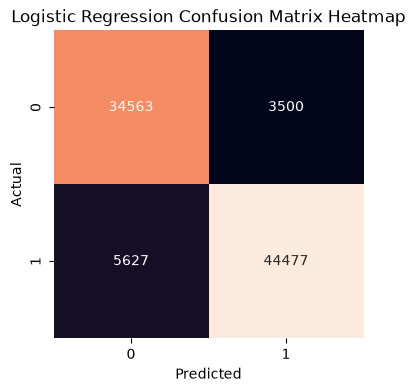

In [15]:

print("Testing Scores::")
report_test = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
print(f"Classification_report: {classification_report(y_test , y_pred)}")
cm = confusion_matrix(y_test , y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm , annot=True ,fmt="d" , cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix Heatmap")
#save the fig 
plt.savefig('../benchmark_outputs/Logistic_Regression_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [16]:
import joblib

# 1. Save your trained pipeline to a file
joblib.dump(lg_pipe, '../models/Logistic_regression_model_pipeline.joblib')


['../models/Logistic_regression_model_pipeline.joblib']